# Fit a 2-D Exponential to a 2-D histogram of star counts from Match Filter
## Charlotte Christensen, June 18, 2026

In [61]:
import numpy as np
from astropy.io import fits
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from pathlib import Path as path
import os
import re

In [62]:
box = 'storm'
num = '2'
galaxy_name = f'{box}_{num}'
numpix=8000

In [63]:
# 1. Define the 2-D exponential model function
# The first argument must accept the combined X and Y coordinate array
def exponential_2d(coords, A, h, q, x_offset, y_offset, theta, C):
    # Parameters: A is amplitude, h is scale length, q is axis ratio (ie., minor/major; related to orientation), 
    # theta is rotation angle in viewing plane, C is offset from background (should be about zero)
    # theta = 0 means major axis is along x-axis, theta = pi/2 means major axis is along y-axis
    x = coords[0] - x_offset
    y = coords[1] - y_offset
    x_prime = x * np.cos(theta) + y * np.sin(theta)
    y_prime = -x * np.sin(theta) + y * np.cos(theta)
    r = np.sqrt(x_prime**2 + y_prime**2/q**2)
    return A * np.exp(-r/h) + C

In [134]:
def twod_exp_fit(d, a, save=True, inv_y=True):

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(7,7))
    my_extent = [-60,60,-60,60]

    # Plot the original noisy data as an image
    im = ax.imshow(masked_residual, origin='lower', extent=my_extent, 
                   cmap='gray', vmin=0, vmax=30)

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    # if cbar.solids is not None:
    #    cbar.solids.set_alpha(0)
    # if hasattr(cbar, 'lines') and isinstance(cbar.lines, list):
    #    for line in cbar.lines:
    #        line.set_alpha(0)
    # cbar.outline.set_alpha(0)
    # cbar.ax.tick_params(axis='both', colors=(0,0,0,0), labelcolor=(0,0,0,0))
    plt.gca().xaxis.set_visible(False)
    plt.gca().yaxis.set_visible(False)
    plt.gca().spines['bottom'].set_visible(True)

    if save==True:
        plt.savefig('exp_fit_90.0.png', dpi=300, bbox_inches='tight', transparent=True)

    if inv_y==True:
        plt.gca().invert_yaxis()
    
    plt.show()

In [122]:
def twod_exp_fit_res(d, a, save=False, inv_y=True):

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot the original noisy data as an image
    im = ax.imshow(masked_residual, origin='lower', extent=[x_line.min(), x_line.max(), y_line.min(), y_line.max()], 
                   cmap='viridis', vmin=-2, vmax=30, aspect='auto')

    # Overlay contours of the fitted result
    #contours = ax.contour(X, Y, Z_fitted, colors='white', linewidths=2, levels=[0.03, 0.3, 8], alpha=0.8)
    #ax.clabel(contours, inline=True, fontsize=8, fmt='%.2f')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Value', rotation=270, labelpad=20)

    # Labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'{galaxy_name} (Image) with Fitted Model Contours (White) Around the Center')

    plt.tight_layout()

    if save==True:
        reduced_path = path(f'sd_outputs/twod_exp_fit/{galaxy_name}/reduced/{galaxy_name}_reduced_d={d}_a={a}_pix={numpix}.png')
        reduced_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(reduced_path)
        hdu = fits.PrimaryHDU(masked_residual)
        exp_save_path = path(f'sd_outputs/twod_exp_fit/{galaxy_name}/fits_files/exp_{galaxy_name}_d={d}_a={a}_pix={numpix}.fits')
        exp_save_path.parent.mkdir(parents=True, exist_ok=True)
        hdu.header['SRC_ID'] = str(exp_save_path)
        hdu.writeto(exp_save_path, overwrite=True)

    if inv_y==True:
        plt.gca().invert_yaxis()

    plt.show()

In [123]:
mf_catalogs_path = path(f'../matched_filter/mf_data/mf_catalogs/{galaxy_name}')
centers_path = path(f'sd_outputs/twod_exp_fit/{galaxy_name}/centers.txt')
centers_path.parent.mkdir(parents=True, exist_ok=True)
best_init_guess_path = path(f'sd_outputs/twod_exp_fit/{galaxy_name}/best_init_guess.txt')
best_init_guess_path.parent.mkdir(parents=True, exist_ok=True)

In [124]:
# Provide a sensible initial guess (p0) to prevent divergence
# Form: [A, h, q, x_offset, y_offset, theta, C]
initial_guess = [1100, 1.05, 1, 5, 0.2, -1.3, 0.1]

update = False

if update == True:
    if os.path.exists(best_init_guess_path):
        os.remove(best_init_guess_path)
    with open(f'{best_init_guess_path}', 'a') as file:
                file.write('Best initial guess for ' f'{galaxy_name}' ': ' \
                           f'{initial_guess[0]}' ', ' \
                           f'{initial_guess[1]}' ', ' \
                           f'{initial_guess[2]}' ', ' \
                           f'{initial_guess[3]}' ', ' \
                           f'{initial_guess[4]}' ', ' \
                           f'{initial_guess[5]}' ', ' \
                           f'{initial_guess[6]}' '.')

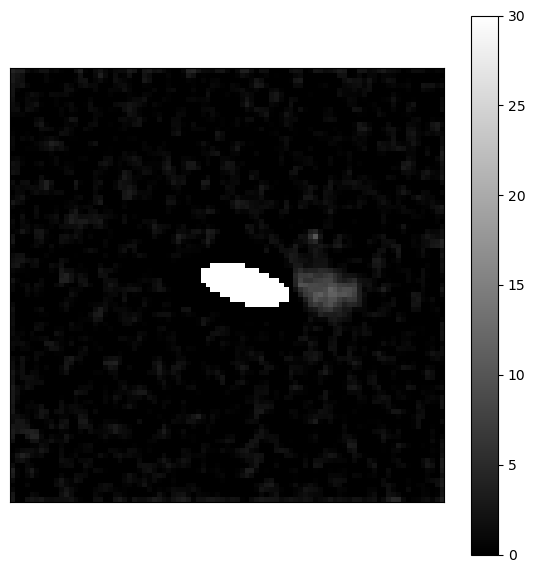

In [135]:
file_name_path = path(f'{mf_catalogs_path}/mf_storm_2_d=90.0_a=77.3_pix=8000.fits')

numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', f'{file_name_path}')]
angles = numbers[1:-1]
d = angles[0]
a = angles[1]

hdul = fits.open(f'{file_name_path}')
data=hdul[0].data

# Generate synthetic mock data with noise
x_line = np.linspace(-60, 60, 89)
y_line = np.linspace(-60, 60, 89)
X, Y = np.meshgrid(x_line, y_line)

# Flatten the arrays to 1-D for curve_fit
x_flat = X.ravel()
y_flat = Y.ravel()
z_flat = data.ravel()

# Combine independent variables into an (2, N) shaped array
independent_vars = np.vstack((x_flat, y_flat))

# Perform the optimization
fitted_params, covariance = curve_fit(
    f=exponential_2d, 
    xdata=independent_vars, 
    ydata=z_flat, 
    p0=initial_guess
)

Z_fitted = exponential_2d((X, Y), *fitted_params)

z_fit_max = np.max(Z_fitted)
mask_thresh = .05 * z_fit_max # Change thresh to what you want
mask = Z_fitted < mask_thresh
residual = data - Z_fitted
masked_residual = residual.copy()
masked_residual[~mask] = np.nan

# Extract and view results

with open(f'{centers_path}', 'a') as file:
    file.write('center of ' f'{galaxy_name}' ' at d=' f'{d}' ' and a=' f'{a}' ':' f'{x_offset_fit:.4f}' ',' f'{y_offset_fit:.4f}' '\n')

twod_exp_fit(d, a, inv_y = False)